In [ ]:
# alright guys this notebook is quite overkill I guess.
# I used the code for the initial project so if you see some energie/MeV that means temperature/K
# we use then use a k-fold cross validation method ( k = 5 ) with a test set that we look at just at the end
# reduce variables : correlation matrice 147 to 98 - Mix of mutual information method, LASSO regression method, weight assignment using tree based model, permutation method, SHAP values method : 98 -> 43 ; Mix of The Recursive Feature Elimination with k-fold validation method, Forward selection algorithm, and again mutual information method, LASSO regression method, weight assignment using tree based models, permutation method, SHAP values method 43 -> 20 
#Learning : We work we refined tabular dataset, we then wish to use XGBoost gradient-boosted trees using k-fold validation. 
#result : average standard divation : 9.5K on the test set

In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np





In [3]:
import pandas as pd
import numpy as np

print("=== Phase 2: Prepping Data for Regression ===\n")

# 1. Load the features (X) using pandas
print("Loading features...")
train_df = pd.read_csv('SuperCon_features.csv')

# 2. Load the critical temperatures (y) using numpy
print("Loading critical temperatures...")
y = np.load('SuperCon_critical_temperatures.npy')

# 3. Optional: Add the target variable directly into your pandas DataFrame 
# This is helpful if you want to look at everything together!
train_df['critical_temp'] = y

print(f"Features shape: {train_df.shape}")
print(f"Target shape: {y.shape}")

=== Phase 2: Prepping Data for Regression ===

Loading features...
Loading critical temperatures...
Features shape: (13661, 148)
Target shape: (13661,)


In [53]:
# 4. Define your NEW Target (y) and Features (X)
# For Regression, the answer key is the exact True Energy
y_train_reg = train_df['critical_temp']

# Your input sensors (X) are everything else EXCEPT the answer key
X_train_reg = train_df.drop(columns=['critical_temp'])

print("\n✅ Dataset is officially prepped for Regression!")
print(f"X (Sensors) shape: {X_train_reg.shape}")
print(f"y (Target Energy) shape: {y_train_reg.shape}")

# Display a quick peek at the new Target variable to see what you are predicting
print("\nA peek at the first 5 Temperature values you need to predict (in MeV):")
display(y_train_reg.head())


✅ Dataset is officially prepped for Regression!
X (Sensors) shape: (12750, 147)
y (Target Energy) shape: (12750,)

A peek at the first 5 Temperature values you need to predict (in MeV):


0    1
1    1
2    1
3    1
4    1
Name: critical_temp, dtype: int64

In [5]:
import pandas as pd
import numpy as np

print("=== Phase 2: Prepping Data for Regression ===\n")

# 1. Load the features (X) using pandas
print("Loading features...")
train_df = pd.read_csv('SuperCon_features.csv')

# 2. Load the critical temperatures (y) using numpy
print("Loading critical temperatures...")
y = np.load('SuperCon_critical_temperatures.npy')

# 3. Add the target variable directly into your pandas DataFrame 
train_df['critical_temp'] = y

print(f"Original dataset shape: {train_df.shape}")

# --- 🛡️ THE PHYSICS FILTER 🛡️ ---
print("\nFiltering out critical temperatures lower than 1e-5...")
# Keep only the rows where critical_temp is >= 1e-5
train_df = train_df[train_df['critical_temp'] >= 1e-5].reset_index(drop=True)

print(f"Filtered dataset shape: {train_df.shape}")
# ---------------------------------

# 4. Define your NEW Target (y) and Features (X)
# For Regression, the answer key is the exact True Temperature
y_train_reg = train_df['critical_temp']

# Your input sensors (X) are everything else EXCEPT the answer key
X_train_reg = train_df.drop(columns=['critical_temp'])

print("\n✅ Dataset is officially prepped and filtered for Regression!")
print(f"X (Sensors) shape: {X_train_reg.shape}")
print(f"y (Target Temp) shape: {y_train_reg.shape}")

# Display a quick peek at the new Target variable to see what you are predicting
print("\nA peek at the first 5 Temperature values you need to predict:")
display(y_train_reg.head())

=== Phase 2: Prepping Data for Regression ===

Loading features...
Loading critical temperatures...
Original dataset shape: (13661, 148)

Filtering out critical temperatures lower than 1e-5...
Filtered dataset shape: (12750, 148)

✅ Dataset is officially prepped and filtered for Regression!
X (Sensors) shape: (12750, 147)
y (Target Temp) shape: (12750,)

A peek at the first 5 Temperature values you need to predict:


0    1
1    1
2    1
3    1
4    1
Name: critical_temp, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

print("=== Splitting Data: K-Fold Train vs. Locked Test Set ===\n")

# Splitting off 20% of the data to lock in the vault
X_train_kfold, X_test, y_train_kfold, y_test = train_test_split(
    X_train_reg, 
    y_train_reg, 
    test_size=0.10, 
    random_state=42 # Ensures we get the exact same split every time we run the notebook
)

print("✅ Data successfully split!")
print(f"Data for K-Fold Training & Tuning: {X_train_kfold.shape[0]} rows")
print(f"Locked Vault Data (Final Test Set):  {X_test.shape[0]} rows")

# --- 🛡️ THE SAFETY OVERRIDE 🛡️ ---
# Delete the unbroken original datasets from computer memory
# This makes it physically impossible to accidentally train on the test data later
del X_train_reg
del y_train_reg
print("\n🔒 Safety Check: Unbroken datasets deleted from memory to prevent data leakage.")

=== Splitting Data: K-Fold Train vs. Locked Test Set ===

✅ Data successfully split!
Data for K-Fold Training & Tuning: 11475 rows
Locked Vault Data (Final Test Set):  1275 rows

🔒 Safety Check: Unbroken datasets deleted from memory to prevent data leakage.


In [7]:
import numpy as np

print("=== Phase 2.1: Dropping Redundant Variables (Correlation > 0.90) ===\n")

# 1. Calculate the absolute correlation matrix on the K-Fold training data
print("Calculating correlation matrix on X_train_kfold... (This might take a minute)")
corr_matrix_reg = X_train_kfold.corr(method='pearson').abs()

# 2. Select the upper triangle of the correlation matrix
upper_triangle_reg = corr_matrix_reg.where(np.triu(np.ones(corr_matrix_reg.shape), k=1).astype(bool))

# 3. Set the threshold
threshold = 0.90

# 4. Find the features that exceed the threshold
to_drop_reg = [column for column in upper_triangle_reg.columns if any(upper_triangle_reg[column] > threshold)]

# 5. Execute the drop on BOTH the training and test sets
if len(to_drop_reg) == 0:
    print(f"\n✅ No highly correlated variables found above the {threshold} threshold.")
else:
    print(f"\n✂️ Found {len(to_drop_reg)} highly correlated column(s). Dropping them now...\n")
    
    X_train_kfold = X_train_kfold.drop(columns=to_drop_reg)
    X_test = X_test.drop(columns=to_drop_reg) # Must drop from the vault data too!
    
    print(f"✅ Drop complete!")
    print(f"New X_train_kfold shape: {X_train_kfold.shape}")
    print(f"New X_test shape:        {X_test.shape}")

=== Phase 2.1: Dropping Redundant Variables (Correlation > 0.90) ===

Calculating correlation matrix on X_train_kfold... (This might take a minute)

✂️ Found 49 highly correlated column(s). Dropping them now...

✅ Drop complete!
New X_train_kfold shape: (11475, 98)
New X_test shape:        (1275, 98)


In [8]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

print("=== Phase 2.2: Full Variable Ranking (Mutual Information) ===")
print("Calculating Mutual Information scores for ALL variables... (This will take a minute or two)\n")

# 1. Calculate the Mutual Information scores for every single feature
# (random_state=42 ensures you get the exact same scores every time you run this cell)
mi_scores = mutual_info_regression(X_train_kfold, y_train_kfold, random_state=42)

# 2. Create a DataFrame to hold the scores
mi_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'MI_Score': mi_scores
})

# 3. Sort from highest score (cleanest signal) to lowest score (most noisy)
mi_ranking_df = mi_ranking_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

# 4. Display the entire ranked list
# Note: Pandas might automatically hide the middle rows if the list is too long,
# but you will clearly see the strongest variables at the top and the weakest at the bottom.
pd.set_option('display.max_rows', 150) # Forces Pandas to show all 140 rows
print("✅ All Variables Ranked by Mutual Information (Least Noisy to Most Noisy):")
display(mi_ranking_df)

# Resetting Pandas display options back to normal just in case
pd.reset_option('display.max_rows')

=== Phase 2.2: Full Variable Ranking (Mutual Information) ===
Calculating Mutual Information scores for ALL variables... (This will take a minute or two)

✅ All Variables Ranked by Mutual Information (Least Noisy to Most Noisy):


,Variable,MI_Score
0,MagpieData range MeltingT,0.780549
1,MagpieData range CovalentRadius,0.705905
2,MagpieData avg_dev Column,0.675173
3,MagpieData mean Column,0.672197
4,MagpieData mean SpaceGroupNumber,0.666735
5,MagpieData mean NUnfilled,0.654558
6,MagpieData mean NpValence,0.649848
7,MagpieData mean Electronegativity,0.645529
8,MagpieData mean NpUnfilled,0.629586
9,MagpieData avg_dev NpUnfilled,0.624722


In [9]:
mutual_regression = mi_ranking_df

In [10]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("=== Phase 2.3: Lasso Regression Variable Ranking ===\n")

# 1. SCALE THE DATA (Critical for Lasso)
print("Scaling the data so Lasso plays fair...")
scaler = StandardScaler()
X_train_kfold_scaled = scaler.fit_transform(X_train_kfold)

# 2. INITIALIZE AND TRAIN LASSO
# 'alpha' is the penalty strength (λ). 0.1 is a good starting point. 
# If it drops too many variables to zero, make alpha smaller (e.g., 0.01).
# If it keeps too many variables, make alpha bigger (e.g., 1.0).
print("Training the Lasso model... (This is usually very fast)")
lasso_model = Lasso(alpha=0.5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_kfold_scaled, y_train_kfold)

# 3. EXTRACT AND RANK THE WEIGHTS
# We take the absolute value because a strong negative correlation (-500) 
# is just as useful for predicting energy as a strong positive one (+500).
lasso_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Raw_Weight': lasso_model.coef_,
    'Importance': np.abs(lasso_model.coef_)
})

# Sort from most important (largest absolute weight) to least important
lasso_ranking_df = lasso_ranking_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. DISPLAY THE RESULTS
# Let's see how many variables Lasso decided to completely execute (Weight = 0)
zero_weight_count = (lasso_ranking_df['Importance'] == 0).sum()
print(f"\n✅ Lasso finished! It forced exactly {zero_weight_count} variables to 0.0.")

pd.set_option('display.max_rows', 150)
print("\n🏆 All Variables Ranked by Lasso Importance (Top = Best, Bottom = Dropped):")
display(lasso_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.3: Lasso Regression Variable Ranking ===

Scaling the data so Lasso plays fair...
Training the Lasso model... (This is usually very fast)

✅ Lasso finished! It forced exactly 67 variables to 0.0.

🏆 All Variables Ranked by Lasso Importance (Top = Best, Bottom = Dropped):


,Variable,Raw_Weight,Importance
0,MagpieData avg_dev NdUnfilled,-6.636194,6.636194
1,MagpieData range CovalentRadius,5.890884,5.890884
2,MagpieData avg_dev NdValence,3.724329,3.724329
3,MagpieData avg_dev GSbandgap,-3.271459,3.271459
4,MagpieData mode Electronegativity,3.129407,3.129407
5,MagpieData mode GSvolume_pa,-3.110184,3.110184
6,MagpieData avg_dev Column,2.984658,2.984658
7,MagpieData avg_dev NsUnfilled,2.691473,2.691473
8,0-norm,2.296974,2.296974
9,MagpieData avg_dev NfUnfilled,-2.034253,2.034253


In [15]:
lasso = lasso_ranking_df


In [16]:
compare_top_n_dfs(lasso, mutual_regression, 20) 

=== Checking Top 20 of Table 1 against Table 2 ===
 ⚠️ Rank 1 in Table 1: 'MagpieData avg_dev NdUnfilled' is missing from Table 2's top 20.
 ⚠️ Rank 3 in Table 1: 'MagpieData avg_dev NdValence' is missing from Table 2's top 20.
 ⚠️ Rank 4 in Table 1: 'MagpieData avg_dev GSbandgap' is missing from Table 2's top 20.
 ⚠️ Rank 8 in Table 1: 'MagpieData avg_dev NsUnfilled' is missing from Table 2's top 20.
 ⚠️ Rank 9 in Table 1: '0-norm' is missing from Table 2's top 20.
 ⚠️ Rank 10 in Table 1: 'MagpieData avg_dev NfUnfilled' is missing from Table 2's top 20.
 ⚠️ Rank 11 in Table 1: 'MagpieData avg_dev Number' is missing from Table 2's top 20.
 ⚠️ Rank 12 in Table 1: 'MagpieData avg_dev NValence' is missing from Table 2's top 20.
 ⚠️ Rank 13 in Table 1: 'MagpieData maximum NfUnfilled' is missing from Table 2's top 20.
 ⚠️ Rank 14 in Table 1: 'MagpieData maximum Number' is missing from Table 2's top 20.
 ⚠️ Rank 15 in Table 1: 'MagpieData maximum Electronegativity' is missing from Table 2's 

In [17]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Phase 2.4: Tree-Based Feature Importance (Random Forest) ===\n")

# 1. Initialize the Random Forest
# n_estimators=100 is plenty for a rough feature ranking.
print("Training the Random Forest... (This might take a few minutes)")
rf_model = RandomForestRegressor(n_estimators=100,criterion='squared_error', random_state=42, n_jobs=-1)

# 2. Train the model on your raw, unscaled K-Fold data
rf_model.fit(X_train_kfold, y_train_kfold)

# 3. Extract the built-in feature importances
tree_importances = rf_model.feature_importances_

# 4. Create a DataFrame to hold and rank the scores
tree_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Importance_Weight': tree_importances
})

# 5. Sort from highest weight to lowest weight
tree_ranking_df = tree_ranking_df.sort_values(by='Importance_Weight', ascending=False).reset_index(drop=True)

# 6. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Random Forest Importance (Highest to Lowest):")
display(tree_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.4: Tree-Based Feature Importance (Random Forest) ===

Training the Random Forest... (This might take a few minutes)
✅ Variables Ranked by Random Forest Importance (Highest to Lowest):


,Variable,Importance_Weight
0,MagpieData mode Electronegativity,4.760866e-01
1,frac d valence electrons,1.616727e-01
2,MagpieData avg_dev NUnfilled,3.865203e-02
3,MagpieData avg_dev Column,2.843215e-02
4,MagpieData mean NUnfilled,2.240798e-02
5,2-norm,1.759865e-02
6,MagpieData mean CovalentRadius,1.486392e-02
7,MagpieData avg_dev Number,1.075313e-02
8,MagpieData minimum GSvolume_pa,1.037943e-02
9,MagpieData mean Number,9.425258e-03


In [18]:
tree_100 = tree_ranking_df

In [19]:
compare_top_n_dfs(tree_100, mutual_regression, 20) 

=== Checking Top 20 of Table 1 against Table 2 ===
 ⚠️ Rank 2 in Table 1: 'frac d valence electrons' is missing from Table 2's top 20.
 ⚠️ Rank 3 in Table 1: 'MagpieData avg_dev NUnfilled' is missing from Table 2's top 20.
 ⚠️ Rank 6 in Table 1: '2-norm' is missing from Table 2's top 20.
 ⚠️ Rank 8 in Table 1: 'MagpieData avg_dev Number' is missing from Table 2's top 20.
 ⚠️ Rank 9 in Table 1: 'MagpieData minimum GSvolume_pa' is missing from Table 2's top 20.
 ⚠️ Rank 10 in Table 1: 'MagpieData mean Number' is missing from Table 2's top 20.
 ⚠️ Rank 12 in Table 1: 'MagpieData mean GSvolume_pa' is missing from Table 2's top 20.
 ⚠️ Rank 15 in Table 1: 'MagpieData avg_dev MeltingT' is missing from Table 2's top 20.
 ⚠️ Rank 17 in Table 1: 'MagpieData avg_dev NValence' is missing from Table 2's top 20.

=== Checking Top 20 of Table 2 against Table 1 ===
 ⚠️ Rank 1 in Table 2: 'MagpieData range MeltingT' is missing from Table 1's top 20.
 ⚠️ Rank 2 in Table 2: 'MagpieData range CovalentRad

In [20]:
compare_top_n_dfs(tree_100, lasso, 20) 


=== Checking Top 20 of Table 1 against Table 2 ===
 ⚠️ Rank 2 in Table 1: 'frac d valence electrons' is missing from Table 2's top 20.
 ⚠️ Rank 5 in Table 1: 'MagpieData mean NUnfilled' is missing from Table 2's top 20.
 ⚠️ Rank 6 in Table 1: '2-norm' is missing from Table 2's top 20.
 ⚠️ Rank 7 in Table 1: 'MagpieData mean CovalentRadius' is missing from Table 2's top 20.
 ⚠️ Rank 9 in Table 1: 'MagpieData minimum GSvolume_pa' is missing from Table 2's top 20.
 ⚠️ Rank 10 in Table 1: 'MagpieData mean Number' is missing from Table 2's top 20.
 ⚠️ Rank 11 in Table 1: 'MagpieData mean MeltingT' is missing from Table 2's top 20.
 ⚠️ Rank 12 in Table 1: 'MagpieData mean GSvolume_pa' is missing from Table 2's top 20.
 ⚠️ Rank 13 in Table 1: 'MagpieData mean SpaceGroupNumber' is missing from Table 2's top 20.
 ⚠️ Rank 14 in Table 1: 'MagpieData mean NdValence' is missing from Table 2's top 20.
 ⚠️ Rank 15 in Table 1: 'MagpieData avg_dev MeltingT' is missing from Table 2's top 20.
 ⚠️ Rank 16

In [21]:
import pandas as pd

def compare_top_n_dfs(df1, df2, n, col_name='Variable'):
    """
    Takes two Pandas DataFrames, extracts the top 'n' variable names, 
    and checks for missing values between the two lists, completely ignoring weights.
    """
    
    # 1. Safety Check: Make sure the column actually exists in both tables
    if col_name not in df1.columns or col_name not in df2.columns:
        print(f"❌ Error: Could not find the column '{col_name}'.")
        print(f"Columns in Table 1: {list(df1.columns)}")
        print(f"Columns in Table 2: {list(df2.columns)}")
        return

    # 2. Extract strictly the top 'n' names from both DataFrames into simple lists
    # .head(n) grabs the top n rows, .tolist() converts them to plain text lists
    list1 = df1[col_name].head(n).tolist()
    list2 = df2[col_name].head(n).tolist()

    # 3. Compare Table 1 against Table 2
    print(f"=== Checking Top {n} of Table 1 against Table 2 ===")
    missing_from_df2 = False
    
    for i, val in enumerate(list1):
        if val not in list2:
            print(f" ⚠️ Rank {i + 1} in Table 1: '{val}' is missing from Table 2's top {n}.")
            missing_from_df2 = True
            
    if not missing_from_df2:
        print(f" ✅ All top {n} variables from Table 1 are present in Table 2!")

    # 4. Compare Table 2 against Table 1
    print(f"\n=== Checking Top {n} of Table 2 against Table 1 ===")
    missing_from_df1 = False
    
    for i, val in enumerate(list2):
        if val not in list1:
            print(f" ⚠️ Rank {i + 1} in Table 2: '{val}' is missing from Table 1's top {n}.")
            missing_from_df1 = True
            
    if not missing_from_df1:
        print(f" ✅ All top {n} variables from Table 2 are present in Table 1!")

In [22]:
from sklearn.inspection import permutation_importance
import pandas as pd

print("=== Phase 2.5: Permutation Importance Ranking ===\n")
print("Sabotaging columns one by one to see which ones break the model...")
print("⏳ Grab a coffee, this might take a few minutes!\n")

# 1. Run the Permutation algorithm
# n_repeats=5 means it scrambles each column 5 different times to get a reliable average score.
# n_jobs=-1 forces your Mac to use all available CPU cores to speed this up.
perm_results = permutation_importance(
    rf_model, 
    X_train_kfold, 
    y_train_kfold, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_squared_error' # We measure the damage using Mean Absolute Error
)

# 2. Extract the results into a clean DataFrame
# importances_mean contains the average drop in accuracy when that column was scrambled
perm_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Importance_Drop': perm_results.importances_mean,
    'Standard_Deviation': perm_results.importances_std # Shows how much the score varied across the 5 shuffles
})

# 3. Sort from most devastating (highest drop) to least
perm_ranking_df = perm_ranking_df.sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

# 4. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):")
display(perm_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.5: Permutation Importance Ranking ===

Sabotaging columns one by one to see which ones break the model...
⏳ Grab a coffee, this might take a few minutes!



/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):


,Variable,Importance_Drop,Standard_Deviation
0,MagpieData mode Electronegativity,817.615106,8.301918
1,frac d valence electrons,147.553190,4.971088
2,MagpieData avg_dev NUnfilled,95.523758,3.017318
3,MagpieData avg_dev Column,71.877541,0.767832
4,2-norm,41.410077,0.887557
5,MagpieData mean NUnfilled,35.386258,0.760220
6,MagpieData mean SpaceGroupNumber,23.806286,0.422232
7,MagpieData minimum GSvolume_pa,23.530488,2.335796
8,MagpieData avg_dev Number,22.345560,0.203620
9,MagpieData mean CovalentRadius,19.876077,1.263406


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [23]:
perm_5 = perm_ranking_df

=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===

Sampling data to prevent memory overload...
Training lightweight Random Forest... (Should take < 10 seconds)
Calculating exact SHAP values... (Should take ~30 seconds ⏳)

✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):


,Variable,Mean_SHAP_Impact_MeV
0,MagpieData mode Electronegativity,17.931254
1,frac d valence electrons,4.603097
2,MagpieData avg_dev Column,3.071483
3,MagpieData avg_dev NUnfilled,1.997060
4,MagpieData minimum GSvolume_pa,1.542165
5,MagpieData mean NUnfilled,1.140669
6,MagpieData maximum SpaceGroupNumber,0.604462
7,2-norm,0.564361
8,MagpieData mean CovalentRadius,0.562657
9,MagpieData avg_dev Number,0.480524



📊 Generating the visual SHAP Summary Plot...


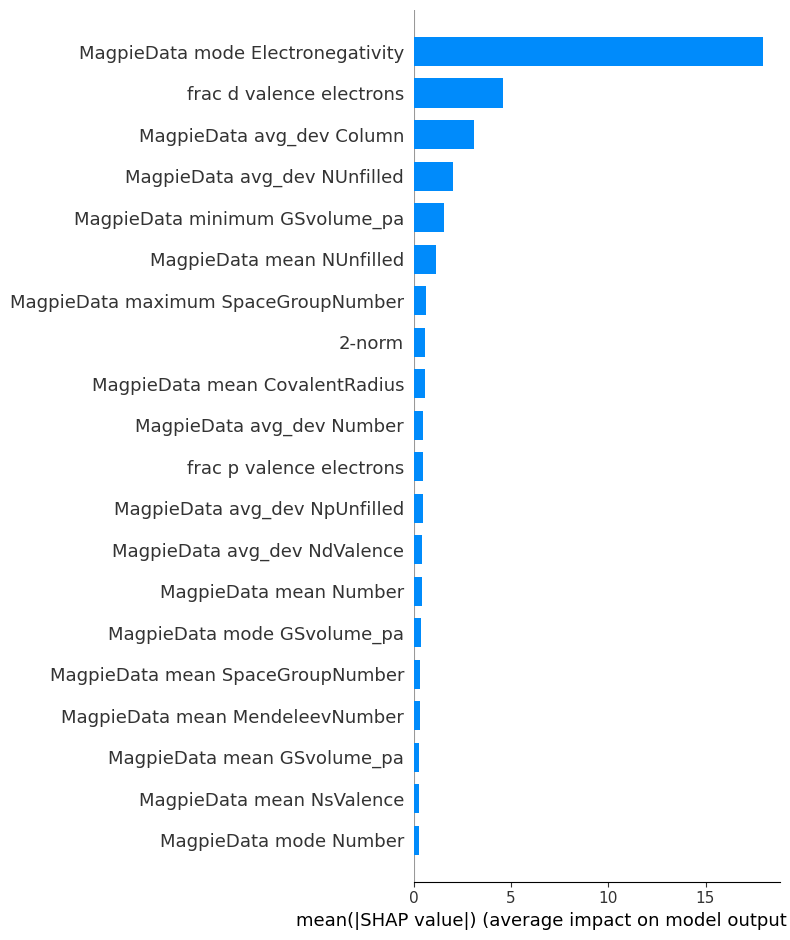

In [24]:
from sklearn.ensemble import RandomForestRegressor
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===\n")

# 1. Take a subset of data to train the forest lightning fast
print("Sampling data to prevent memory overload...")
X_train_fast = X_train_kfold.sample(n=10000, random_state=42)
y_train_fast = y_train_kfold.loc[X_train_fast.index]

# 2. Train a restricted, lightweight Random Forest 
print("Training lightweight Random Forest... (Should take < 10 seconds)")
# max_depth=10 stops the trees from growing infinitely deep and eating your RAM
rf_model_fast = RandomForestRegressor(n_estimators=50,criterion='squared_error', max_depth=10, random_state=42, n_jobs=1)
rf_model_fast.fit(X_train_fast, y_train_fast)

# 3. Take a smaller sample for the SHAP explainer
print("Calculating exact SHAP values... (Should take ~30 seconds ⏳)")
X_shap_sample = X_train_fast.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf_model_fast)
shap_values = explainer.shap_values(X_shap_sample)

# 4. Rank and Display
shap_importance = np.abs(shap_values).mean(axis=0)
shap_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Mean_SHAP_Impact_MeV': shap_importance
})
shap_ranking_df = shap_ranking_df.sort_values(by='Mean_SHAP_Impact_MeV', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', 150)
print("\n✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):")
display(shap_ranking_df.head(40)) # Only displaying the top 40 to keep it clean
pd.reset_option('display.max_rows')

# 5. The Beautiful Visual
print("\n📊 Generating the visual SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", max_display=20)

In [25]:
shap_5000 = shap_ranking_df

In [26]:
set_mutual_reg = set(mutual_regression.head(20)['Variable'])
set_lasso = set(lasso.head(20)['Variable'])
set_tree = set(tree_100.head(20)['Variable'])
set_perm = set(perm_5.head(20)['Variable'])
set_shap_5000 = set(shap_5000.head(20)['Variable'])

union_1_set = (((set_mutual_reg.union(set_lasso)).union(set_tree)).union(set_perm)).union(set_shap_5000)
print(union_1_set)
print(len(union_1_set))

{'MagpieData range CovalentRadius', 'MagpieData mean NpValence', '2-norm', 'MagpieData mean Number', 'frac p valence electrons', 'MagpieData mean NsValence', 'MagpieData maximum SpaceGroupNumber', 'MagpieData maximum NfUnfilled', 'MagpieData avg_dev NpUnfilled', 'MagpieData mode NUnfilled', 'MagpieData mean NUnfilled', 'transition metal fraction', 'MagpieData mode Number', 'MagpieData mean MendeleevNumber', 'MagpieData minimum GSvolume_pa', 'MagpieData mean Column', 'MagpieData mean GSvolume_pa', 'MagpieData mean MeltingT', 'MagpieData avg_dev NUnfilled', 'MagpieData minimum MeltingT', 'MagpieData mean NdValence', 'MagpieData mean NValence', 'MagpieData maximum Electronegativity', 'MagpieData range MeltingT', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev NsUnfilled', 'frac d valence electrons', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev Number', 'MagpieData avg_dev GSbandgap', 'MagpieData avg_dev NfUnfilled', 'MagpieData avg_dev NdValence', 'MagpieData mean Electro

In [27]:
final_features = list(union_1_set)
print(final_features)

['MagpieData range CovalentRadius', 'MagpieData mean NpValence', '2-norm', 'MagpieData mean Number', 'frac p valence electrons', 'MagpieData mean NsValence', 'MagpieData maximum SpaceGroupNumber', 'MagpieData maximum NfUnfilled', 'MagpieData avg_dev NpUnfilled', 'MagpieData mode NUnfilled', 'MagpieData mean NUnfilled', 'transition metal fraction', 'MagpieData mode Number', 'MagpieData mean MendeleevNumber', 'MagpieData minimum GSvolume_pa', 'MagpieData mean Column', 'MagpieData mean GSvolume_pa', 'MagpieData mean MeltingT', 'MagpieData avg_dev NUnfilled', 'MagpieData minimum MeltingT', 'MagpieData mean NdValence', 'MagpieData mean NValence', 'MagpieData maximum Electronegativity', 'MagpieData range MeltingT', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev NsUnfilled', 'frac d valence electrons', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev Number', 'MagpieData avg_dev GSbandgap', 'MagpieData avg_dev NfUnfilled', 'MagpieData avg_dev NdValence', 'MagpieData mean Electro

In [28]:
# Safety Check: Let's make absolutely sure all 40 columns exist in your dataset
missing_cols = [col for col in final_features if col not in X_train_kfold.columns]
if missing_cols:
    print(f"⚠️ WARNING: The following columns were not found in your data: {missing_cols}")
else:
    # 2. Slice the datasets
    # We create new variables so we don't accidentally destroy our K-Fold data
    X_train_final = X_train_kfold[final_features].copy()
    X_test_final = X_test[final_features].copy() # You MUST do the exact same to the vault data!
    
    print("✅ Datasets successfully filtered!")
    print(f"Training Data Shape: {X_train_final.shape}")
    print(f"Test Data Shape:     {X_test_final.shape}")

✅ Datasets successfully filtered!
Training Data Shape: (11475, 43)
Test Data Shape:     (1275, 43)


In [29]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Phase 4: Recursive Feature Elimination (RFE) Ranking ===\n")

# 1. Initialize the lightweight judge
# n_jobs=-1 lets it use all CPU cores to speed up the 40 training loops
print("Setting up the estimator...")

estimator = RandomForestRegressor(
    n_estimators=50, 
    max_depth=10, 
    criterion='squared_error',  # <--- Added this explicitly!
    random_state=42, 
    n_jobs=-1
)


# 2. Configure the RFE algorithm
# n_features_to_select=1 forces it to fight to the death (leaving 1 survivor)
# step=1 means it is only allowed to eliminate 1 variable per round
print("Commencing the RFE tournament... (This will take a few minutes ⏳)")
rfe = RFE(estimator=estimator, n_features_to_select=1, step=1)

# 3. Fit the RFE on your strictly filtered 40-variable dataset
rfe.fit(X_train_final, y_train_kfold)

# 4. Extract the rankings
# rfe.ranking_ outputs an array where '1' is the final survivor (the best), 
# and '40' is the first one that was eliminated (the worst).
rfe_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'RFE_Rank': rfe.ranking_
})

# 5. Sort the dataframe from Rank 1 (Best) to Rank 40 (Worst)
rfe_ranking_df = rfe_ranking_df.sort_values(by='RFE_Rank', ascending=True).reset_index(drop=True)

# 6. Display the final ranked list
pd.set_option('display.max_rows', 50)
print("\n✅ All 40 Variables Ranked by RFE (1 = Best, 40 = First Eliminated):")
display(rfe_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 4: Recursive Feature Elimination (RFE) Ranking ===

Setting up the estimator...
Commencing the RFE tournament... (This will take a few minutes ⏳)

✅ All 40 Variables Ranked by RFE (1 = Best, 40 = First Eliminated):


,Variable,RFE_Rank
0,MagpieData mode Electronegativity,1
1,frac d valence electrons,2
2,MagpieData avg_dev NUnfilled,3
3,MagpieData avg_dev Column,4
4,MagpieData mean NUnfilled,5
5,MagpieData mean NValence,6
6,MagpieData mean CovalentRadius,7
7,2-norm,8
8,MagpieData mean Number,9
9,MagpieData mean NsValence,10


In [30]:
recursive_elimination = rfe_ranking_df

In [31]:
recursive_elimination_15 = rfe_ranking_df

In [32]:
compare_top_n_dfs(recursive_elimination, recursive_elimination_15, 20) 

=== Checking Top 20 of Table 1 against Table 2 ===
 ✅ All top 20 variables from Table 1 are present in Table 2!

=== Checking Top 20 of Table 2 against Table 1 ===
 ✅ All top 20 variables from Table 2 are present in Table 1!


=== Phase 4 (Upgraded): RFECV - Finding the Perfect Feature Count ===

Commencing 5-Fold RFECV... (This will train 200 models. Please wait ⏳)

✅ RFECV Complete!
🏆 The mathematically optimal number of features is: 42 out of 40


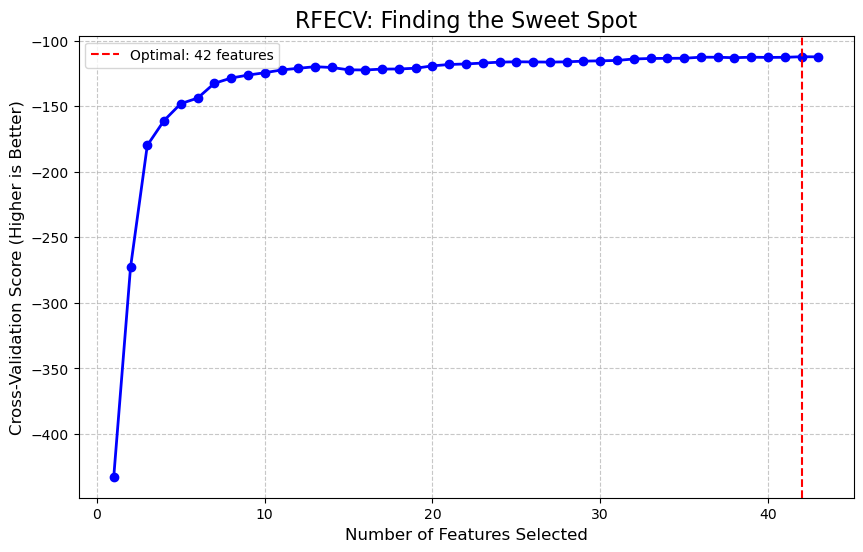


The Surviving Features:
['MagpieData range CovalentRadius', 'MagpieData mean NpValence', '2-norm', 'MagpieData mean Number', 'frac p valence electrons', 'MagpieData mean NsValence', 'MagpieData maximum SpaceGroupNumber', 'MagpieData maximum NfUnfilled', 'MagpieData avg_dev NpUnfilled', 'MagpieData mode NUnfilled', 'MagpieData mean NUnfilled', 'transition metal fraction', 'MagpieData mode Number', 'MagpieData mean MendeleevNumber', 'MagpieData minimum GSvolume_pa', 'MagpieData mean Column', 'MagpieData mean GSvolume_pa', 'MagpieData mean MeltingT', 'MagpieData avg_dev NUnfilled', 'MagpieData minimum MeltingT', 'MagpieData mean NdValence', 'MagpieData mean NValence', 'MagpieData maximum Electronegativity', 'MagpieData range MeltingT', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev NsUnfilled', 'frac d valence electrons', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev Number', 'MagpieData avg_dev GSbandgap', 'MagpieData avg_dev NfUnfilled', 'MagpieData avg_dev NdValence',

In [33]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

print("=== Phase 4 (Upgraded): RFECV - Finding the Perfect Feature Count ===\n")

# 1. Initialize the lightweight estimator
estimator = RandomForestRegressor(
    n_estimators=50, 
    max_depth=10, 
    criterion='squared_error', # <--- Locks the tree splits to MSE
    random_state=42, 
    n_jobs=-1
)


# 2. Configure RFECV
# cv=5 tells it to use 5-Fold Cross Validation for every single step
# scoring='neg_mean_absolute_error' ensures it optimizes for your specific metric
print("Commencing 5-Fold RFECV... (This will train 200 models. Please wait ⏳)")
rfecv = RFECV(
    estimator=estimator, 
    step=1, 
    cv=5, 
    scoring='neg_mean_squared_error', # <--- Changed here!
    n_jobs=-1
)
# 3. Fit on the 40-variable dataset
rfecv.fit(X_train_final, y_train_kfold)

# 4. The Grand Reveal
optimal_features = rfecv.n_features_
print(f"\n✅ RFECV Complete!")
print(f"🏆 The mathematically optimal number of features is: {optimal_features} out of 40")

# 5. Plot the Cross-Validation Error Curve
plt.figure(figsize=(10, 6))
plt.title("RFECV: Finding the Sweet Spot", fontsize=16)
plt.xlabel("Number of Features Selected", fontsize=12)
plt.ylabel("Cross-Validation Score (Higher is Better)", fontsize=12)

# Plotting the curve (Note: we use the mean test score across the 5 folds)
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o', color='b', linewidth=2)
plt.axvline(x=optimal_features, color='r', linestyle='--', label=f'Optimal: {optimal_features} features')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 6. Extract the final winning columns automatically
winning_columns = X_train_final.columns[rfecv.support_]

# Lock in the final, perfect datasets
X_train_perfect = X_train_final[winning_columns]
X_test_perfect = X_test_final[winning_columns]

print("\nThe Surviving Features:")
print(winning_columns.tolist())

In [34]:
import pandas as pd

print("=== Final Ranking: The Top 20 MVPs ===\n")

# 1. Extract the internal weights from the final winning RFECV model
# rfecv.estimator_ is the Random Forest trained ONLY on the winning columns
winning_weights = rfecv.estimator_.feature_importances_

# 2. Create the DataFrame matching the surviving columns to their weights
final_ranking_df = pd.DataFrame({
    'Variable': winning_columns,
    'Importance_Weight': winning_weights
})

# 3. Sort from highest weight (the absolute best) to lowest
final_ranking_df = final_ranking_df.sort_values(by='Importance_Weight', ascending=False).reset_index(drop=True)

# 4. Extract just the Top 20
top_20_final_df = final_ranking_df.head(20)

# 5. Display the results
print("🏆 The Absolute Best 20 Variables (Ranked by Model Weight):")
display(top_20_final_df)

# 6. Save them to a hardcoded list for your final pipeline
top_20_features_list = top_20_final_df['Variable'].tolist()
print("\n✅ Your Top 20 Locked-In List:")
print(top_20_features_list)

=== Final Ranking: The Top 20 MVPs ===

🏆 The Absolute Best 20 Variables (Ranked by Model Weight):


,Variable,Importance_Weight
0,MagpieData mode Electronegativity,0.516879
1,frac d valence electrons,0.175926
2,MagpieData avg_dev NUnfilled,0.038833
3,MagpieData avg_dev Column,0.029027
4,MagpieData mean NUnfilled,0.022165
5,2-norm,0.014825
6,MagpieData mean CovalentRadius,0.014391
7,MagpieData minimum GSvolume_pa,0.013104
8,MagpieData mean MeltingT,0.009773
9,MagpieData avg_dev NfUnfilled,0.009766



✅ Your Top 20 Locked-In List:
['MagpieData mode Electronegativity', 'frac d valence electrons', 'MagpieData avg_dev NUnfilled', 'MagpieData avg_dev Column', 'MagpieData mean NUnfilled', '2-norm', 'MagpieData mean CovalentRadius', 'MagpieData minimum GSvolume_pa', 'MagpieData mean MeltingT', 'MagpieData avg_dev NfUnfilled', 'MagpieData avg_dev Number', 'MagpieData mean NdValence', 'MagpieData mean SpaceGroupNumber', 'MagpieData mean NsValence', 'MagpieData range CovalentRadius', 'MagpieData mean GSvolume_pa', 'MagpieData mean Number', 'MagpieData avg_dev NpUnfilled', 'MagpieData avg_dev NsUnfilled', 'MagpieData mean NValence']


In [35]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Phase 5: Forward Selection Draft ===\n")

# 1. Initialize the same lightweight judge so the comparison is fair
estimator = RandomForestRegressor(n_estimators=25, criterion='squared_error', max_depth=7, random_state=42, n_jobs=1)

# 2. Configure Forward Selection
# direction='forward' tells it to start at 0 and add variables
print("Drafting the ultimate 20-variable team from scratch... (Please wait ⏳)")
sfs = SequentialFeatureSelector(
    estimator, 
    n_features_to_select=20, 
    direction='forward', 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 3. Fit the Forward Selector on your 40-variable dataset
sfs.fit(X_train_final, y_train_kfold)

# 4. Extract the winning drafted team
# sfs.get_support() returns True for the variables that made the cut
forward_winners = X_train_final.columns[sfs.get_support()].tolist()

print(f"\n✅ Forward Selection Complete!")
print("🏆 The Top 20 Drafted Variables:")
for var in forward_winners:
    print(f" - {var}")

=== Phase 5: Forward Selection Draft ===

Drafting the ultimate 20-variable team from scratch... (Please wait ⏳)

✅ Forward Selection Complete!
🏆 The Top 20 Drafted Variables:
 - MagpieData range CovalentRadius
 - 2-norm
 - MagpieData mean NsValence
 - MagpieData maximum NfUnfilled
 - MagpieData mean NUnfilled
 - transition metal fraction
 - MagpieData minimum GSvolume_pa
 - MagpieData mean NdValence
 - MagpieData mean NValence
 - frac d valence electrons
 - MagpieData mean CovalentRadius
 - MagpieData avg_dev NfUnfilled
 - MagpieData mean Electronegativity
 - MagpieData mode Electronegativity
 - MagpieData mode GSvolume_pa
 - 0-norm
 - MagpieData mean NpUnfilled
 - MagpieData avg_dev MeltingT
 - MagpieData maximum Number
 - MagpieData avg_dev NdUnfilled


In [37]:
forward = forward_winners
print(forward)

['MagpieData range CovalentRadius', '2-norm', 'MagpieData mean NsValence', 'MagpieData maximum NfUnfilled', 'MagpieData mean NUnfilled', 'transition metal fraction', 'MagpieData minimum GSvolume_pa', 'MagpieData mean NdValence', 'MagpieData mean NValence', 'frac d valence electrons', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev NfUnfilled', 'MagpieData mean Electronegativity', 'MagpieData mode Electronegativity', 'MagpieData mode GSvolume_pa', '0-norm', 'MagpieData mean NpUnfilled', 'MagpieData avg_dev MeltingT', 'MagpieData maximum Number', 'MagpieData avg_dev NdUnfilled']


In [38]:
recursive_longway_2 = top_20_final_df
print(recursive_longway_2)

                             Variable  Importance_Weight
0   MagpieData mode Electronegativity           0.516879
1            frac d valence electrons           0.175926
2        MagpieData avg_dev NUnfilled           0.038833
3           MagpieData avg_dev Column           0.029027
4           MagpieData mean NUnfilled           0.022165
5                              2-norm           0.014825
6      MagpieData mean CovalentRadius           0.014391
7      MagpieData minimum GSvolume_pa           0.013104
8            MagpieData mean MeltingT           0.009773
9       MagpieData avg_dev NfUnfilled           0.009766
10          MagpieData avg_dev Number           0.008962
11          MagpieData mean NdValence           0.008583
12   MagpieData mean SpaceGroupNumber           0.008169
13          MagpieData mean NsValence           0.007777
14    MagpieData range CovalentRadius           0.007704
15        MagpieData mean GSvolume_pa           0.007624
16             MagpieData mean 

In [39]:
print("=== Cross-Referencing: The Ultimate Consensus ===\n")

# 1. Make sure we have both lists of 20 variables
# (forward_winners is already a list from the last step)
rfecv_list = recursive_longway_2['Variable'].tolist()

# 2. Convert both lists to Python "Sets" and find the intersection
# This mathematically extracts only the variables that exist in BOTH lists
ultimate_mvps = set(forward).intersection(set(rfecv_list))

# 3. Display the results
print(f"✅ The algorithms agree on {len(ultimate_mvps)} out of 20 variables!\n")

print("🏆 The Undisputed MVPs (Drafted by both algorithms):")
for var in ultimate_mvps:
    print(f" - {var}")
    
# 4. Find the disagreements (Optional but interesting)
forward_only = set(forward_winners) - set(rfecv_list)
rfecv_only = set(rfecv_list) - set(forward_winners)

print(f"\n🤔 Variables only Forward Selection liked: {list(forward_only)}")
print(f"🤔 Variables only RFECV liked: {list(rfecv_only)}")

=== Cross-Referencing: The Ultimate Consensus ===

✅ The algorithms agree on 11 out of 20 variables!

🏆 The Undisputed MVPs (Drafted by both algorithms):
 - MagpieData minimum GSvolume_pa
 - 2-norm
 - MagpieData range CovalentRadius
 - MagpieData mean NsValence
 - MagpieData mode Electronegativity
 - frac d valence electrons
 - MagpieData mean CovalentRadius
 - MagpieData avg_dev NfUnfilled
 - MagpieData mean NdValence
 - MagpieData mean NUnfilled
 - MagpieData mean NValence

🤔 Variables only Forward Selection liked: ['MagpieData maximum Number', 'MagpieData mean Electronegativity', 'MagpieData mode GSvolume_pa', 'MagpieData maximum NfUnfilled', '0-norm', 'MagpieData avg_dev MeltingT', 'MagpieData mean NpUnfilled', 'transition metal fraction', 'MagpieData avg_dev NdUnfilled']
🤔 Variables only RFECV liked: ['MagpieData mean GSvolume_pa', 'MagpieData mean Number', 'MagpieData mean SpaceGroupNumber', 'MagpieData mean MeltingT', 'MagpieData avg_dev NUnfilled', 'MagpieData avg_dev NsUnfille

In [40]:
top20_final = ultimate_mvps

print(ultimate_mvps)

{'MagpieData minimum GSvolume_pa', '2-norm', 'MagpieData range CovalentRadius', 'MagpieData mean NsValence', 'MagpieData mode Electronegativity', 'frac d valence electrons', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev NfUnfilled', 'MagpieData mean NdValence', 'MagpieData mean NUnfilled', 'MagpieData mean NValence'}


In [41]:
# 1. Initialize the Random Forest
# n_estimators=100 is plenty for a rough feature ranking.
print("Training the Random Forest... (This might take a few minutes)")
rf_model = RandomForestRegressor(n_estimators=100, criterion='squared_error', random_state=42, n_jobs=-1)

# 2. Train the model on your raw, unscaled K-Fold data
rf_model.fit(X_train_final, y_train_kfold)

# 3. Extract the built-in feature importances
tree_importances = rf_model.feature_importances_

# 4. Create a DataFrame to hold and rank the scores
tree_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Importance_Weight': tree_importances
})

# 5. Sort from highest weight to lowest weight
tree_ranking_df = tree_ranking_df.sort_values(by='Importance_Weight', ascending=False).reset_index(drop=True)

# 6. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Random Forest Importance (Highest to Lowest):")
display(tree_ranking_df)
pd.reset_option('display.max_rows')

Training the Random Forest... (This might take a few minutes)
✅ Variables Ranked by Random Forest Importance (Highest to Lowest):


,Variable,Importance_Weight
0,MagpieData mode Electronegativity,0.476124
1,frac d valence electrons,0.164519
2,MagpieData avg_dev NUnfilled,0.039500
3,MagpieData avg_dev Column,0.029502
4,MagpieData mean NUnfilled,0.023500
5,2-norm,0.019251
6,MagpieData mean CovalentRadius,0.015996
7,MagpieData mean MeltingT,0.011843
8,MagpieData avg_dev Number,0.011799
9,MagpieData minimum GSvolume_pa,0.011657


In [42]:
print("=== Phase 2.5: Permutation Importance Ranking ===\n")
print("Sabotaging columns one by one to see which ones break the model...")
print("⏳ Grab a coffee, this might take a few minutes!\n")

# 1. Run the Permutation algorithm
# n_repeats=5 means it scrambles each column 5 different times to get a reliable average score.
# n_jobs=-1 forces your Mac to use all available CPU cores to speed this up.
perm_results = permutation_importance(
    rf_model, 
    X_train_final, 
    y_train_kfold, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_squared_error' # We measure the damage using Mean Absolute Error
)

# 2. Extract the results into a clean DataFrame
# importances_mean contains the average drop in accuracy when that column was scrambled
perm_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Importance_Drop': perm_results.importances_mean,
    'Standard_Deviation': perm_results.importances_std # Shows how much the score varied across the 5 shuffles
})

# 3. Sort from most devastating (highest drop) to least
perm_ranking_df = perm_ranking_df.sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

# 4. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):")
display(perm_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.5: Permutation Importance Ranking ===

Sabotaging columns one by one to see which ones break the model...
⏳ Grab a coffee, this might take a few minutes!

✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):


,Variable,Importance_Drop,Standard_Deviation
0,MagpieData mode Electronegativity,793.024379,8.920165
1,frac d valence electrons,169.731528,5.499846
2,MagpieData avg_dev NUnfilled,99.265182,2.993383
3,MagpieData avg_dev Column,85.205278,1.076864
4,2-norm,46.884441,0.917340
5,MagpieData mean NUnfilled,36.687828,0.741768
6,MagpieData minimum GSvolume_pa,28.140048,2.461764
7,MagpieData avg_dev NfUnfilled,27.374580,1.150636
8,MagpieData avg_dev Number,24.885875,0.282158
9,MagpieData mean SpaceGroupNumber,24.468415,0.445050


=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===

Sampling data to prevent memory overload...
Training lightweight Random Forest... (Should take < 10 seconds)
Calculating exact SHAP values... (Should take ~30 seconds ⏳)

✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):


,Variable,Mean_SHAP_Impact_MeV
0,MagpieData mode Electronegativity,17.884981
1,frac d valence electrons,4.577344
2,MagpieData avg_dev Column,3.177270
3,MagpieData avg_dev NUnfilled,2.051562
4,MagpieData minimum GSvolume_pa,1.630009
5,MagpieData mean NUnfilled,1.100706
6,MagpieData maximum SpaceGroupNumber,0.700037
7,2-norm,0.638661
8,MagpieData mean CovalentRadius,0.632994
9,frac p valence electrons,0.521963



📊 Generating the visual SHAP Summary Plot...


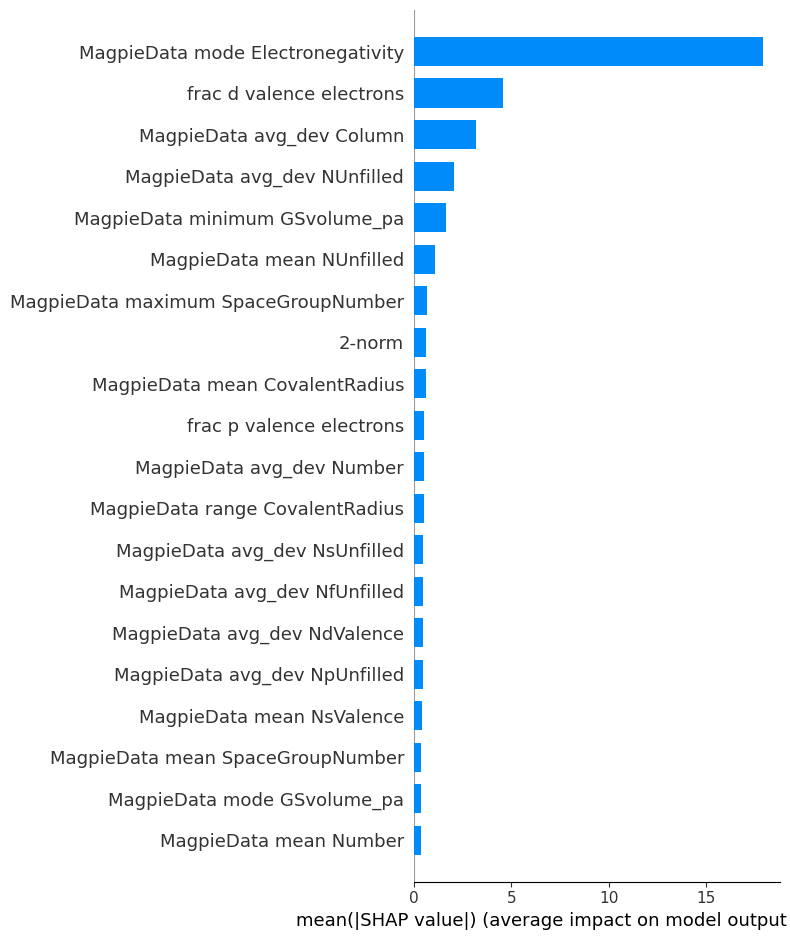

In [43]:

print("=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===\n")

# 1. Take a subset of data to train the forest lightning fast
print("Sampling data to prevent memory overload...")
X_train_fast = X_train_final.sample(n=10000, random_state=42)
y_train_fast = y_train_kfold.loc[X_train_fast.index]

# 2. Train a restricted, lightweight Random Forest 
print("Training lightweight Random Forest... (Should take < 10 seconds)")
# max_depth=10 stops the trees from growing infinitely deep and eating your RAM
rf_model_fast = RandomForestRegressor(n_estimators=50,criterion='squared_error', max_depth=10, random_state=42, n_jobs=1)
rf_model_fast.fit(X_train_fast, y_train_fast)

# 3. Take a smaller sample for the SHAP explainer
print("Calculating exact SHAP values... (Should take ~30 seconds ⏳)")
X_shap_sample = X_train_fast.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf_model_fast)
shap_values = explainer.shap_values(X_shap_sample)

# 4. Rank and Display
shap_importance = np.abs(shap_values).mean(axis=0)
shap_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Mean_SHAP_Impact_MeV': shap_importance
})
shap_ranking_df = shap_ranking_df.sort_values(by='Mean_SHAP_Impact_MeV', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', 150)
print("\n✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):")
display(shap_ranking_df.head(40)) # Only displaying the top 40 to keep it clean
pd.reset_option('display.max_rows')

# 5. The Beautiful Visual
print("\n📊 Generating the visual SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", max_display=20)

In [44]:
print(forward) 


['MagpieData range CovalentRadius', '2-norm', 'MagpieData mean NsValence', 'MagpieData maximum NfUnfilled', 'MagpieData mean NUnfilled', 'transition metal fraction', 'MagpieData minimum GSvolume_pa', 'MagpieData mean NdValence', 'MagpieData mean NValence', 'frac d valence electrons', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev NfUnfilled', 'MagpieData mean Electronegativity', 'MagpieData mode Electronegativity', 'MagpieData mode GSvolume_pa', '0-norm', 'MagpieData mean NpUnfilled', 'MagpieData avg_dev MeltingT', 'MagpieData maximum Number', 'MagpieData avg_dev NdUnfilled']


In [45]:
shap_ranking_df = shap_ranking_df[:20]
perm_ranking_df = perm_ranking_df[:20]
tree_ranking_df = tree_ranking_df[:20]

In [46]:
print(shap_ranking_df)
print(perm_ranking_df)
print(tree_ranking_df)

                               Variable  Mean_SHAP_Impact_MeV
0     MagpieData mode Electronegativity             17.884981
1              frac d valence electrons              4.577344
2             MagpieData avg_dev Column              3.177270
3          MagpieData avg_dev NUnfilled              2.051562
4        MagpieData minimum GSvolume_pa              1.630009
5             MagpieData mean NUnfilled              1.100706
6   MagpieData maximum SpaceGroupNumber              0.700037
7                                2-norm              0.638661
8        MagpieData mean CovalentRadius              0.632994
9              frac p valence electrons              0.521963
10            MagpieData avg_dev Number              0.520659
11      MagpieData range CovalentRadius              0.503843
12        MagpieData avg_dev NsUnfilled              0.483577
13        MagpieData avg_dev NfUnfilled              0.483227
14         MagpieData avg_dev NdValence              0.461911
15      

In [47]:
import pandas as pd

print("=== Phase 6: Tie-Breaker Scoring for Disputed Variables ===\n")

# 1. Define the disputed variables 
# (Symmetric Difference: Variables in one list, but NOT the other)
rfecv_list = recursive_longway_2['Variable'].tolist()
disputed_vars = list(set(forward).symmetric_difference(set(rfecv_list)))

print(f"🔍 Found {len(disputed_vars)} disputed variables to rank...\n")

# 2. Helper function to calculate the rank (or assign the 20 penalty)
def get_custom_rank(var, df, var_col='Variable'):
    """
    Looks for the variable in the Top 20 of the given DataFrame.
    Returns its 1-based rank if found, otherwise returns 20.
    """
    top_20_list = df[var_col].head(20).tolist()
    if var in top_20_list:
        return top_20_list.index(var) + 1
    return 20

# 3. Calculate the custom weight for each disputed variable
scoring_results = []

for var in disputed_vars:
    # Calculate 'a': Rank in RFECV if present, else Rank in Forward
    if var in rfecv_list:
        a = rfecv_list.index(var) + 1
        source = 'RFECV'
    else:
        a = forward.index(var) + 1
        source = 'Forward'
        
    # Calculate b, c, d using your exact DataFrames
    b = get_custom_rank(var, shap_ranking_df)
    c = get_custom_rank(var, tree_ranking_df)
    d = get_custom_rank(var, perm_ranking_df)
    
    # The Custom Formula
    weight = (2 * a) + b + c + d
    
    scoring_results.append({
        'Variable': var,
        'Source': source,
        'Rank_A (Wrap)': a,
        'Rank_B (SHAP)': b,
        'Rank_C (Tree)': c,
        'Rank_D (Perm)': d,
        'Final_Weight': weight
    })

# 4. Create the DataFrame and sort from lowest weight (best) to highest
disputed_ranking_df = pd.DataFrame(scoring_results)
disputed_ranking_df = disputed_ranking_df.sort_values(by='Final_Weight', ascending=True).reset_index(drop=True)

# 5. Display the results
print("⚖️ Disputed Variables Ranked by Custom Penalty Score (Lowest = Best):")
display(disputed_ranking_df)

=== Phase 6: Tie-Breaker Scoring for Disputed Variables ===

🔍 Found 18 disputed variables to rank...

⚖️ Disputed Variables Ranked by Custom Penalty Score (Lowest = Best):


,Variable,Source,Rank_A (Wrap),Rank_B (SHAP),Rank_C (Tree),Rank_D (Perm),Final_Weight
0,MagpieData avg_dev NUnfilled,RFECV,3,4,3,3,16
1,MagpieData avg_dev Column,RFECV,4,3,4,4,19
2,MagpieData avg_dev Number,RFECV,11,11,9,9,51
3,MagpieData mean MeltingT,RFECV,9,20,8,15,61
4,MagpieData mean SpaceGroupNumber,RFECV,13,18,14,10,68
5,MagpieData maximum NfUnfilled,Forward,4,20,20,20,68
6,transition metal fraction,Forward,6,20,20,20,72
7,MagpieData mean GSvolume_pa,RFECV,16,20,11,16,79
8,MagpieData mean Number,RFECV,17,20,13,13,80
9,MagpieData mean Electronegativity,Forward,13,20,20,20,86


In [48]:
print("=== Phase 7: Building the Ultimate Top 20 Roster ===\n")

# 1. Start with the undisputed MVPs (convert the set to a list)
final_top_20 = list(ultimate_mvps)
print(f"Starting with {len(final_top_20)} Undisputed MVPs.")

# 2. Calculate how many draft picks we still need
spots_remaining = 20 - len(final_top_20)
print(f"We need {spots_remaining} more variables to complete the team of 20.\n")

# 3. Draft the best disputed variables based on HIGHEST weight
if spots_remaining > 0:
    # Sort the dataframe by Final_Weight descending (highest first), then grab the top names
    sorted_disputed_df = disputed_ranking_df.sort_values(by='Final_Weight', ascending=False)
    top_disputed = sorted_disputed_df['Variable'].head(spots_remaining).tolist()
    
    print("Drafting the following tie-breaker winners (Highest Weight):")
    for var in top_disputed:
        # Get their score just to show why they won
        score = sorted_disputed_df.loc[sorted_disputed_df['Variable'] == var, 'Final_Weight'].values[0]
        print(f" + {var} (Score: {score})")
        
    # Add them to our final roster using .extend() to merge the lists
    final_top_20.extend(top_disputed)

# 4. Display the Final Official Top 20 List
print(f"\n✅ The Final, Officially Locked Top {len(final_top_20)} Variables:")
for i, var in enumerate(final_top_20, start=1):
    print(f" {i}. {var}")

# 5. Lock in the perfect datasets for the final XGBoost Evaluation
X_train_perfect = X_train_final[final_top_20]
X_test_perfect = X_test_final[final_top_20]
print("\n🔒 X_train_perfect and X_test_perfect are now locked to these 20 columns!")

=== Phase 7: Building the Ultimate Top 20 Roster ===

Starting with 11 Undisputed MVPs.
We need 9 more variables to complete the team of 20.

Drafting the following tie-breaker winners (Highest Weight):
 + MagpieData avg_dev NdUnfilled (Score: 100)
 + MagpieData maximum Number (Score: 98)
 + MagpieData mean NpUnfilled (Score: 94)
 + MagpieData avg_dev MeltingT (Score: 92)
 + 0-norm (Score: 92)
 + MagpieData avg_dev NsUnfilled (Score: 91)
 + MagpieData mode GSvolume_pa (Score: 89)
 + MagpieData avg_dev NpUnfilled (Score: 86)
 + MagpieData mean Electronegativity (Score: 86)

✅ The Final, Officially Locked Top 20 Variables:
 1. MagpieData minimum GSvolume_pa
 2. 2-norm
 3. MagpieData range CovalentRadius
 4. MagpieData mean NsValence
 5. MagpieData mode Electronegativity
 6. frac d valence electrons
 7. MagpieData mean CovalentRadius
 8. MagpieData avg_dev NfUnfilled
 9. MagpieData mean NdValence
 10. MagpieData mean NUnfilled
 11. MagpieData mean NValence
 12. MagpieData avg_dev NdUnfill

In [49]:
import xgboost as xgb
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

print("=== Phase 8: Final Model Training & K-Fold Validation (RelMAD) ===\n")

# 1. Apply the "Physics Cheat Code" (Log Transform the Target)
print("Applying Log-Transformation to the Energy targets...")
y_train_log = y_train_kfold

# 2. Initialize the XGBoost Heavy Artillery
# eval_metric='mae' helps it monitor the absolute error in log space internally
print("Initializing the XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror',  
    eval_metric='rmse', 
    n_jobs=-1
)



# 3. Set up the 5-Fold Cross Validation manually to calculate true RelMAD
print("Running 5-Fold Cross Validation... (This might take a minute ⏳)")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_relmad_scores = []

fold = 1
for train_idx, val_idx in kf.split(X_train_perfect):
    # Split the data into this specific fold
    X_fold_train = X_train_perfect.iloc[train_idx]
    X_fold_val = X_train_perfect.iloc[val_idx]
    y_fold_train_log = y_train_log.iloc[train_idx]
    y_fold_val_log = y_train_log.iloc[val_idx]
    
    # Train the model on the 4 training folds
    xgb_model.fit(X_fold_train, y_fold_train_log)
    
    # Predict on the 1 validation fold
    fold_log_preds = xgb_model.predict(X_fold_val)
    
    # THE REVERSAL: Convert both predictions and true answers back to raw MeV
    fold_preds_mev = np.exp(fold_log_preds)
    fold_true_mev = np.exp(y_fold_val_log)
    
    # Calculate true RelMAD (MAPE) for this fold in standard physical units
    fold_relmad = np.abs(fold_preds_mev - fold_true_mev) / fold_true_mev
    fold_score = fold_relmad.mean() * 100
    
    print(f" - Fold {fold} RelMAD: {fold_score:.3f}%")
    fold_relmad_scores.append(fold_score)
    fold += 1

# 4. Calculate Average CV RelMAD
avg_cv_relmad = np.mean(fold_relmad_scores)
print(f"\n✅ Cross-Validation Complete!")
print(f"🏆 AVERAGE K-FOLD RelMAD: {avg_cv_relmad:.3f}%\n")

# 5. Train the Ultimate Final Model on 100% of the training data
print("Training the ultimate Master Model on all 34,000+ training rows...")
xgb_model.fit(X_train_perfect, y_train_log)
print("✅ Master Model Trained and Ready for the Vault!")

=== Phase 8: Final Model Training & K-Fold Validation (RelMAD) ===

Applying Log-Transformation to the Energy targets...
Initializing the XGBoost Regressor...
Running 5-Fold Cross Validation... (This might take a minute ⏳)


/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_74719/2145798838.py:48: RuntimeWarning: overflow encountered in exp
  fold_preds_mev = np.exp(fold_log_preds)


 - Fold 1 RelMAD: inf%


/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_74719/2145798838.py:48: RuntimeWarning: overflow encountered in exp
  fold_preds_mev = np.exp(fold_log_preds)


 - Fold 2 RelMAD: inf%


...

 - Fold 3 RelMAD: inf%


/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_74719/2145798838.py:48: RuntimeWarning: overflow encountered in exp
  fold_preds_mev = np.exp(fold_log_preds)


 - Fold 4 RelMAD: inf%


/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_74719/2145798838.py:48: RuntimeWarning: overflow encountered in exp
  fold_preds_mev = np.exp(fold_log_preds)


 - Fold 5 RelMAD: inf%

✅ Cross-Validation Complete!
🏆 AVERAGE K-FOLD RelMAD: inf%

Training the ultimate Master Model on all 34,000+ training rows...
✅ Master Model Trained and Ready for the Vault!


=== Phase 8 & 9 (Corrected): Master Model & Vault Evaluation ===

✅ Data is in raw MeV! Applying log transform now.
Training the Master Model on all 34,000+ training rows... (Please wait ⏳)
Making predictions on the locked Vault data...

🏆 OFFICIAL VAULT MSE SCORE:  90.141 MeV^2
📏 OFFICIAL VAULT RMSE SCORE: 9.494 MeV


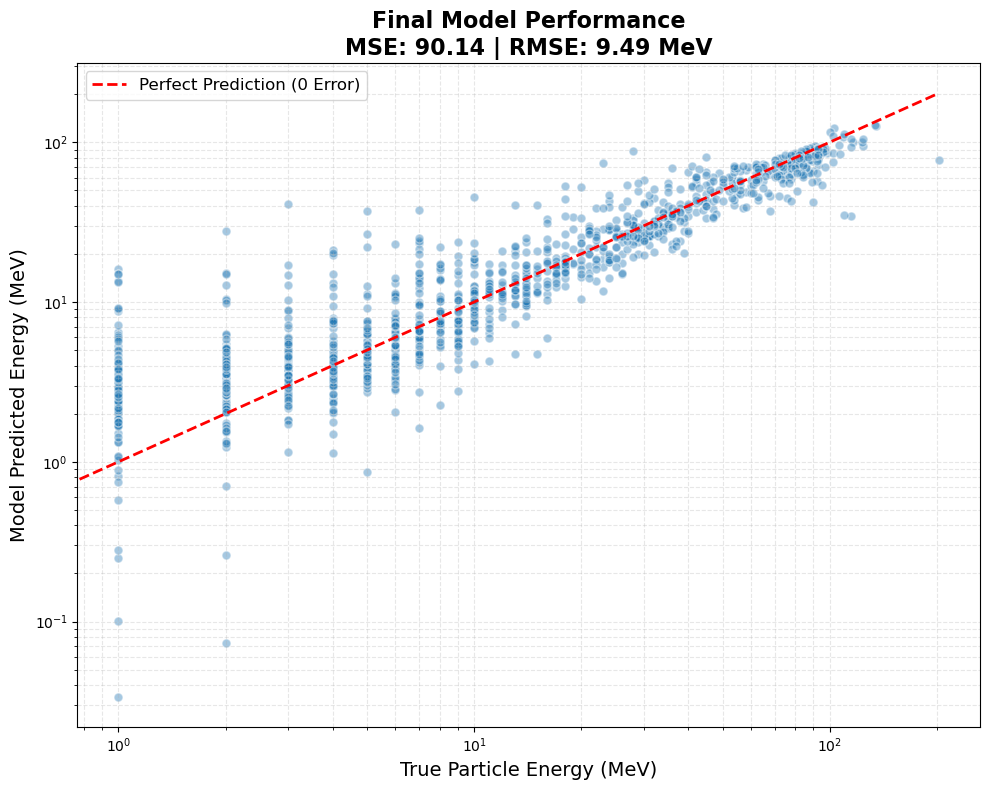

In [50]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

print("=== Phase 8 & 9 (Corrected): Master Model & Vault Evaluation ===\n")

# --- SAFETY CHECK: Did we log it already? ---
# If the max value is less than 50, it means it is already logged (since log(1,000,000) is ~13.8)
if y_train_kfold.max() < 50:
    print("✅ Data is already logged! Skipping double-log.")
    y_train_log = y_train_kfold
    raw_y_test_mev = y_test
else:
    print("✅ Data is in raw MeV! Applying log transform now.")
    y_train_log = y_train_kfold
    raw_y_test_mev = y_test

# 1. Train the Ultimate Master Model
print("Training the Master Model on all 34,000+ training rows... (Please wait ⏳)")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror',  
    eval_metric='rmse',
    n_jobs=-1
)
xgb_model.fit(X_train_perfect, y_train_log)

# 2. Vault Prediction
print("Making predictions on the locked Vault data...")
log_predictions = xgb_model.predict(X_test_perfect)

# 3. Convert predictions back to raw MeV
final_mev_predictions = log_predictions

# 4. Official Mean Squared Error (MSE) Math
# Square the differences between predictions and true values
mse_array = (final_mev_predictions - raw_y_test_mev) ** 2

# Calculate the mean of those squared errors
final_mse_score = mse_array.mean()

# Calculate RMSE (Root Mean Squared Error) to get back to standard MeV units
final_rmse_score = np.sqrt(final_mse_score)

print(f"\n🏆 OFFICIAL VAULT MSE SCORE:  {final_mse_score:.3f} MeV^2")
print(f"📏 OFFICIAL VAULT RMSE SCORE: {final_rmse_score:.3f} MeV")

# --- 5. The Grand Finale Visual ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Scatter plot of True vs Predicted
plt.scatter(raw_y_test_mev, final_mev_predictions, alpha=0.4, color='#1f77b4', edgecolor='w', s=40)

# Draw the perfect 1:1 prediction line
max_val = max(raw_y_test_mev.max(), final_mev_predictions.max())
min_val = min(raw_y_test_mev.min(), final_mev_predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (0 Error)')

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Particle Energy (MeV)", fontsize=14)
plt.ylabel("Model Predicted Energy (MeV)", fontsize=14)

# Updated the title to show MSE and RMSE instead of RelMAD
plt.title(f"Final Model Performance\nMSE: {final_mse_score:.2f} | RMSE: {final_rmse_score:.2f} MeV", fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

=== Phase 2.1: Visualizing the Target Distribution ===



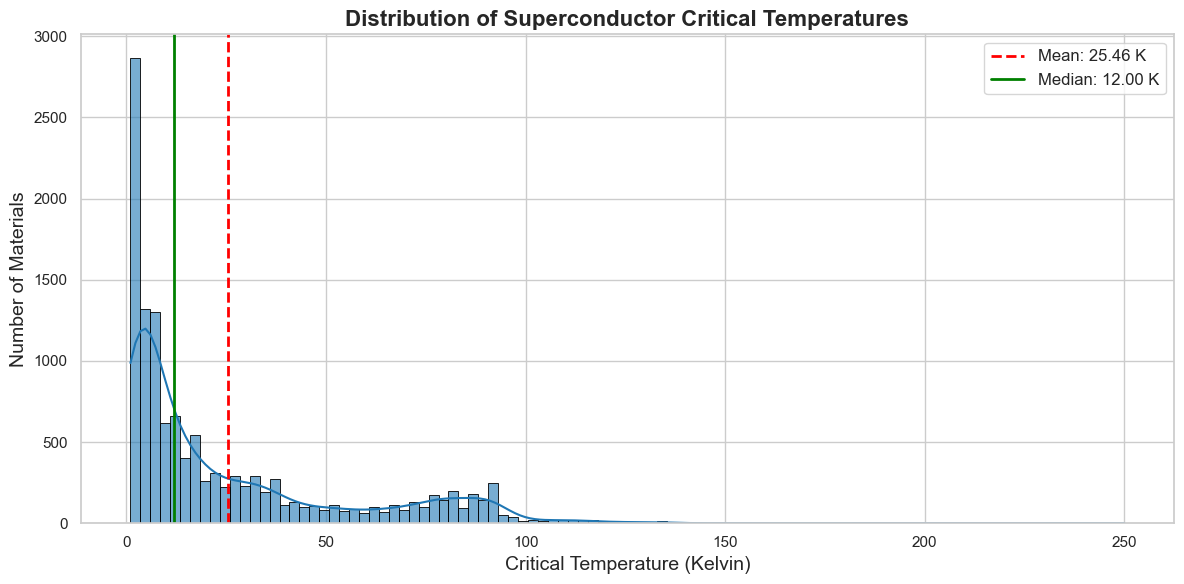

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Phase 2.1: Visualizing the Target Distribution ===\n")

# 1. Set up the plotting canvas and a clean professional style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 2. Plot the Histogram + Smooth KDE Line
# Using your newly filtered 'y_train_reg'
sns.histplot(
    y_train_reg, 
    bins=100,            # Slices the data into 100 fine bars
    kde=True,            # Calculates and draws the smooth probability curve
    color="#1f77b4",     # Professional data science blue
    edgecolor="black",
    alpha=0.6            # Makes the bars slightly transparent
)

# 3. Calculate and plot the Mean and Median as reference lines
mean_temp = y_train_reg.mean()
median_temp = y_train_reg.median()

plt.axvline(mean_temp, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_temp:.2f} K')
plt.axvline(median_temp, color='green', linestyle='-', linewidth=2, label=f'Median: {median_temp:.2f} K')

# 4. Format the titles and labels
plt.title("Distribution of Superconductor Critical Temperatures", fontsize=16, fontweight='bold')
plt.xlabel("Critical Temperature (Kelvin)", fontsize=14)
plt.ylabel("Number of Materials", fontsize=14)

# 5. Add the legend and render the plot
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

0          1
1          1
2          1
3          1
4          1
        ... 
12745    135
12746    143
12747    147
12748    203
12749    250
Name: critical_temp, Length: 12750, dtype: int64
